## CNN in PyTorch on Synthetic Images


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt


Generate vertical vs horizontal pattern images


In [2]:
torch.manual_seed(42)

def make_images(n_samples=1200, size=28):
    images = torch.zeros(n_samples, 1, size, size)
    labels = torch.zeros(n_samples, dtype=torch.long)

    for i in range(n_samples):
        img = torch.randn(size, size) * 0.08
        cls = torch.randint(0, 2, (1,)).item()

        if cls == 0:
            col = torch.randint(8, 20, (1,)).item()
            img[:, col-1:col+1] += 1.2
        else:
            row = torch.randint(8, 20, (1,)).item()
            img[row-1:row+1, :] += 1.2

        images[i, 0] = img.clamp(0, 1)
        labels[i] = cls

    return images, labels

X, y = make_images()
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
print(X_train.shape, y_train.shape)


torch.Size([960, 1, 28, 28]) torch.Size([960])


Build and train CNN


In [3]:
cnn = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(32 * 7 * 7, 32),
    nn.ReLU(),
    nn.Linear(32, 2)
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001)

for epoch in range(10):
    cnn.train()
    for xb, yb in train_loader:
        logits = cnn(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

cnn.eval()
with torch.no_grad():
    logits = cnn(X_test)
    pred = logits.argmax(dim=1)
    acc = (pred == y_test).float().mean().item()

print(f"CNN test accuracy: {acc:.4f}")


CNN test accuracy: 1.0000


Visualize sample predictions


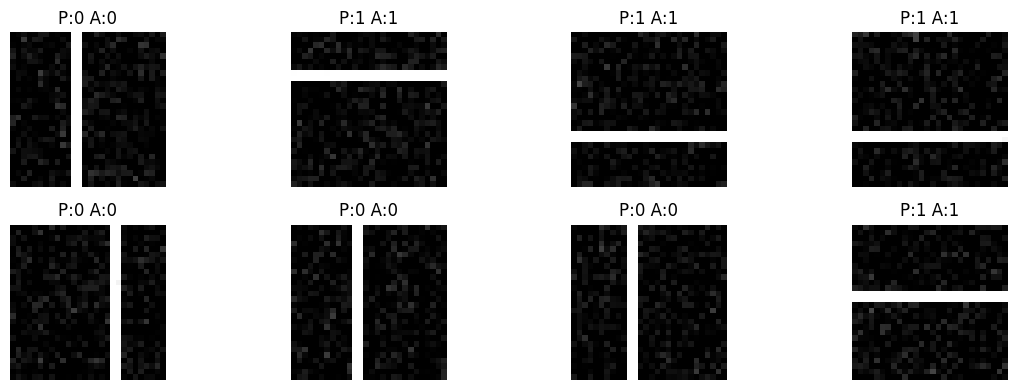

In [4]:
cnn.eval()
with torch.no_grad():
    sample_logits = cnn(X_test[:8])
    sample_pred = sample_logits.argmax(dim=1)

plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_test[i, 0], cmap='gray')
    plt.title(f"P:{sample_pred[i].item()} A:{y_test[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()
